# 1. Setup and Imports

This notebook keeps the workflow compact:
- load MLSUM language by language
- show only one full language dataset object
- run a short EDA for balance and outliers
- clean and balance the training data
- prepare the final dataset and start training
- end with one short ROUGE check


In [1]:
import subprocess
import sys

required_packages = [
    "datasets==3.6.0",
    "transformers",
    "sentencepiece",
    "accelerate",
    "pandas",
    "matplotlib",
    "rouge_score",
    "absl-py",
]

print("Installing required packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])
print("Installation finished.")

Installing required packages...
Installation finished.


In [2]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets
import torch

from datasets import DatasetDict, concatenate_datasets, load_dataset
from transformers import set_seed

warnings.filterwarnings("ignore")
%matplotlib inline

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [3]:
SEED = 42
DATASET_NAME = "reciTAL/mlsum"

LANGUAGE_CODES = ["de", "es", "fr", "ru", "tr"]
HF_LANGUAGE_CONFIGS = {
    "de": "de",
    "es": "es",
    "fr": "fr",
    "ru": "ru",
    "tr": "tu",
}
LANGUAGE_NAMES = {
    "de": "German",
    "es": "Spanish",
    "fr": "French",
    "ru": "Russian",
    "tr": "Turkish",
}

TEXT_COLUMN = "text"
SUMMARY_COLUMN = "summary"
LANGUAGE_COLUMN = "language"
ARTICLE_WORD_COUNT_COLUMN = "article_word_count"
SUMMARY_WORD_COUNT_COLUMN = "summary_word_count"

MODEL_NAME = "google/mt5-small"
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 96

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    set_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"datasets version: {datasets.__version__}")
print(f"pandas version:   {pd.__version__}")
print(f"torch version:    {torch.__version__}")
print(f"device:           {DEVICE}")

datasets version: 3.6.0
pandas version:   2.2.2
torch version:    2.10.0+cpu
device:           cpu


# 2. Load the Data

The dataset is loaded per language. To keep the notebook tidy, only one full language dataset object is displayed afterwards.


In [4]:
def load_mlsum_language(hf_config_name: str) -> DatasetDict:
    return load_dataset(DATASET_NAME, hf_config_name)


def add_language_column(dataset_dict: DatasetDict, language_code: str) -> DatasetDict:
    return DatasetDict(
        {
            split_name: split_dataset.add_column(LANGUAGE_COLUMN, [language_code] * len(split_dataset))
            for split_name, split_dataset in dataset_dict.items()
        }
    )


datasets_by_language = {}

for language_code in LANGUAGE_CODES:
    hf_config_name = HF_LANGUAGE_CONFIGS[language_code]
    print(f"Loading {language_code} from Hugging Face config '{hf_config_name}'...")
    dataset_dict = load_mlsum_language(hf_config_name)
    datasets_by_language[language_code] = add_language_column(dataset_dict, language_code)

print("All language datasets loaded.")

Loading de from Hugging Face config 'de'...


README.md: 0.00B [00:00, ?B/s]

mlsum.py: 0.00B [00:00, ?B/s]

The repository for reciTAL/mlsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/reciTAL/mlsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/220887 [00:00<?, ? examples/s]

...

Loading tr from Hugging Face config 'tu'...


Generating train split:   0%|          | 0/249277 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11565 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12775 [00:00<?, ? examples/s]

All language datasets loaded.


In [5]:
dataset_size_rows = []

for language_code in LANGUAGE_CODES:
    dataset_dict = datasets_by_language[language_code]
    dataset_size_rows.append(
        {
            "language_code": language_code,
            "language_name": LANGUAGE_NAMES[language_code],
            "train_rows": len(dataset_dict["train"]),
            "validation_rows": len(dataset_dict["validation"]),
            "test_rows": len(dataset_dict["test"]),
        }
    )

dataset_size_df = pd.DataFrame(dataset_size_rows)
dataset_size_df

,language_code,language_name,train_rows,validation_rows,test_rows
0,de,German,220887,11394,10701
1,es,Spanish,266367,10358,13920
2,fr,French,392902,16059,15828
3,ru,Russian,25556,750,757
4,tr,Turkish,249277,11565,12775


In [6]:
datasets_by_language["de"]

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date', 'language'],
        num_rows: 220887
    })
    validation: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date', 'language'],
        num_rows: 11394
    })
    test: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date', 'language'],
        num_rows: 10701
    })
})

# 3. Compact EDA

The EDA stays short and focuses on three questions:
1. Are the training languages balanced?
2. How different are article and summary lengths?
3. How many examples look like clear length outliers?


In [7]:
def count_words(text) -> int:
    if not isinstance(text, str):
        return 0
    return len(text.split())


def add_word_count_columns(batch):
    return {
        ARTICLE_WORD_COUNT_COLUMN: [count_words(text) for text in batch[TEXT_COLUMN]],
        SUMMARY_WORD_COUNT_COLUMN: [count_words(summary) for summary in batch[SUMMARY_COLUMN]],
    }


datasets_with_lengths_by_language = {}

for language_code in LANGUAGE_CODES:
    print(f"Adding word-count columns for {language_code}...")
    datasets_with_lengths_by_language[language_code] = DatasetDict(
        {
            split_name: split_dataset.map(
                add_word_count_columns,
                batched=True,
                desc=f"Word counts for {language_code}-{split_name}",
            )
            for split_name, split_dataset in datasets_by_language[language_code].items()
        }
    )

print("Word-count columns added to all splits.")

Adding word-count columns for de...


Word counts for de-train:   0%|          | 0/220887 [00:00<?, ? examples/s]

Word counts for de-validation:   0%|          | 0/11394 [00:00<?, ? examples/s]

Word counts for de-test:   0%|          | 0/10701 [00:00<?, ? examples/s]

Adding word-count columns for es...


...

Adding word-count columns for tr...


Word counts for tr-train:   0%|          | 0/249277 [00:00<?, ? examples/s]

Word counts for tr-validation:   0%|          | 0/11565 [00:00<?, ? examples/s]

Word counts for tr-test:   0%|          | 0/12775 [00:00<?, ? examples/s]

Word-count columns added to all splits.


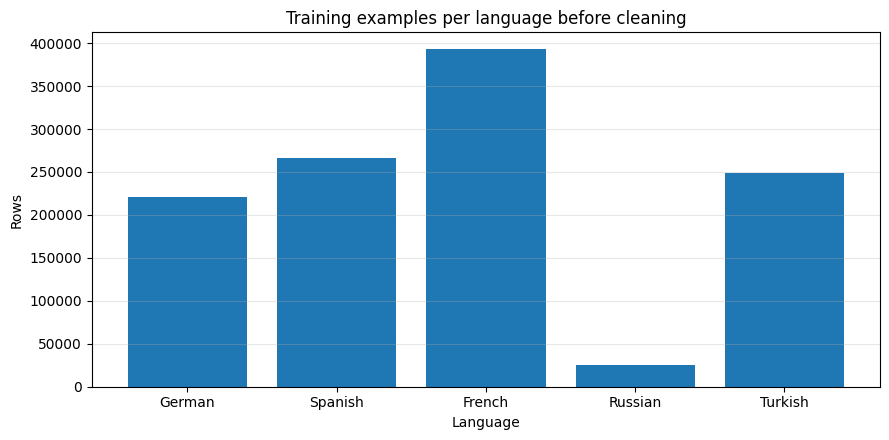

In [8]:
train_count_df = dataset_size_df[["language_code", "language_name", "train_rows"]].copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(train_count_df["language_name"], train_count_df["train_rows"])
ax.set_title("Training examples per language before cleaning")
ax.set_xlabel("Language")
ax.set_ylabel("Rows")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
EDA_SAMPLE_PER_LANGUAGE = 3000

eda_frames = []

for language_code in LANGUAGE_CODES:
    train_split = datasets_with_lengths_by_language[language_code]["train"]
    sample_size = min(EDA_SAMPLE_PER_LANGUAGE, len(train_split))
    sampled_split = train_split.shuffle(seed=SEED).select(range(sample_size))

    eda_frames.append(
        pd.DataFrame(
            {
                "language_code": sampled_split[LANGUAGE_COLUMN],
                "language_name": [LANGUAGE_NAMES[language_code]] * sample_size,
                ARTICLE_WORD_COUNT_COLUMN: sampled_split[ARTICLE_WORD_COUNT_COLUMN],
                SUMMARY_WORD_COUNT_COLUMN: sampled_split[SUMMARY_WORD_COUNT_COLUMN],
            }
        )
    )

eda_sample_df = pd.concat(eda_frames, ignore_index=True)
eda_sample_df.head()

,language_code,language_name,article_word_count,summary_word_count
0,de,German,304,20
1,de,German,306,43
2,de,German,681,31
3,de,German,323,31
4,de,German,470,51


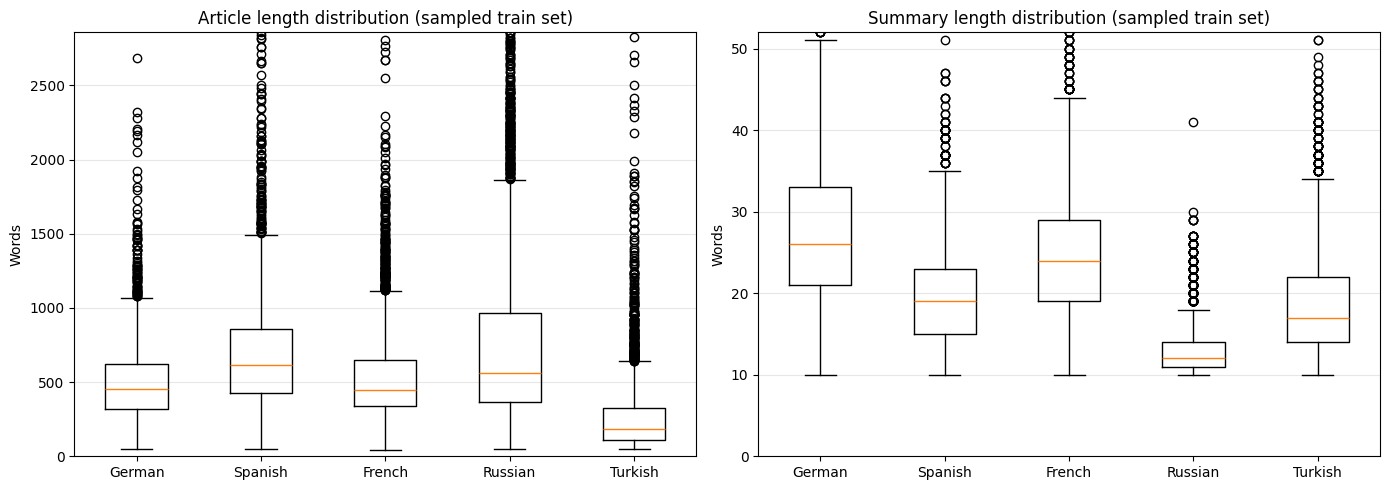

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

article_data = [
    eda_sample_df.loc[eda_sample_df["language_code"] == language_code, ARTICLE_WORD_COUNT_COLUMN]
    for language_code in LANGUAGE_CODES
]
summary_data = [
    eda_sample_df.loc[eda_sample_df["language_code"] == language_code, SUMMARY_WORD_COUNT_COLUMN]
    for language_code in LANGUAGE_CODES
]
labels = [LANGUAGE_NAMES[language_code] for language_code in LANGUAGE_CODES]

axes[0].boxplot(article_data, labels=labels, showfliers=True)
axes[0].set_title("Article length distribution (sampled train set)")
axes[0].set_ylabel("Words")
axes[0].set_ylim(0, np.percentile(eda_sample_df[ARTICLE_WORD_COUNT_COLUMN], 99.5))
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(summary_data, labels=labels, showfliers=True)
axes[1].set_title("Summary length distribution (sampled train set)")
axes[1].set_ylabel("Words")
axes[1].set_ylim(0, np.percentile(eda_sample_df[SUMMARY_WORD_COUNT_COLUMN], 99.5))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
threshold_rows = []
outlier_rate_rows = []

for language_code in LANGUAGE_CODES:
    train_split = datasets_with_lengths_by_language[language_code]["train"]
    article_counts = np.asarray(train_split[ARTICLE_WORD_COUNT_COLUMN], dtype=np.int32)
    summary_counts = np.asarray(train_split[SUMMARY_WORD_COUNT_COLUMN], dtype=np.int32)

    article_min = max(40, int(np.floor(np.quantile(article_counts, 0.01))))
    article_max = int(np.ceil(np.quantile(article_counts, 0.99)))
    summary_min = max(4, int(np.floor(np.quantile(summary_counts, 0.01))))
    summary_max = int(np.ceil(np.quantile(summary_counts, 0.99)))

    article_outlier_rate = ((article_counts < article_min) | (article_counts > article_max)).mean() * 100
    summary_outlier_rate = ((summary_counts < summary_min) | (summary_counts > summary_max)).mean() * 100
    any_outlier_rate = (
        (
            (article_counts < article_min)
            | (article_counts > article_max)
            | (summary_counts < summary_min)
            | (summary_counts > summary_max)
        ).mean() * 100
    )

    threshold_rows.append(
        {
            "language_code": language_code,
            "language_name": LANGUAGE_NAMES[language_code],
            "article_min": article_min,
            "article_max": article_max,
            "summary_min": summary_min,
            "summary_max": summary_max,
        }
    )

    outlier_rate_rows.append(
        {
            "language_code": language_code,
            "language_name": LANGUAGE_NAMES[language_code],
            "article_outlier_rate_pct": round(float(article_outlier_rate), 2),
            "summary_outlier_rate_pct": round(float(summary_outlier_rate), 2),
            "any_outlier_rate_pct": round(float(any_outlier_rate), 2),
        }
    )

thresholds_df = pd.DataFrame(threshold_rows)
outlier_rate_df = pd.DataFrame(outlier_rate_rows)

thresholds_df

,language_code,language_name,article_min,article_max,summary_min,summary_max
0,de,German,81,1350,11,52
1,es,Spanish,51,2388,10,38
2,fr,French,62,1763,11,49
3,ru,Russian,85,3075,10,25
4,tr,Turkish,52,1359,10,44


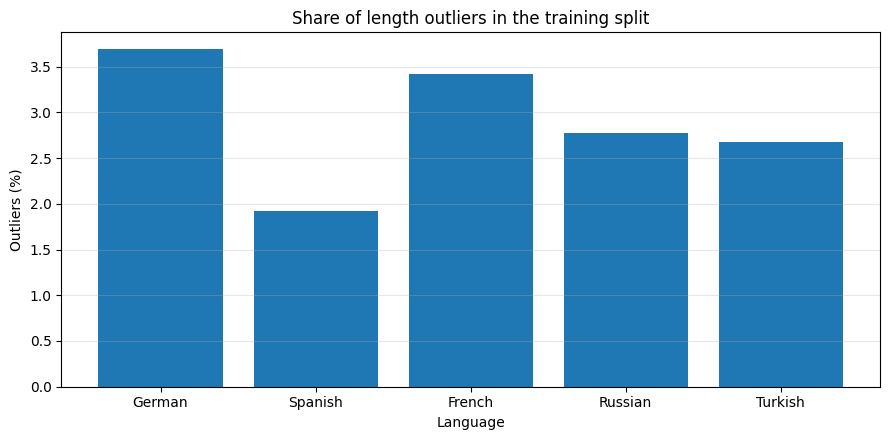

,language_code,language_name,article_outlier_rate_pct,summary_outlier_rate_pct,any_outlier_rate_pct
0,de,German,1.97,1.77,3.69
1,es,Spanish,1.03,0.95,1.92
2,fr,French,1.93,1.54,3.42
3,ru,Russian,2.00,0.83,2.77
4,tr,Turkish,1.72,0.97,2.68


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(outlier_rate_df["language_name"], outlier_rate_df["any_outlier_rate_pct"])
ax.set_title("Share of length outliers in the training split")
ax.set_xlabel("Language")
ax.set_ylabel("Outliers (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

outlier_rate_df

# 4. Cleaning

Cleaning uses only thresholds learned from the training split of each language.
This avoids leakage from validation or test data.


In [13]:
threshold_map = {
    row["language_code"]: {
        "article_min": row["article_min"],
        "article_max": row["article_max"],
        "summary_min": row["summary_min"],
        "summary_max": row["summary_max"],
    }
    for _, row in thresholds_df.iterrows()
}


def is_non_empty_text(value) -> bool:
    return isinstance(value, str) and len(value.strip()) > 0


def filter_dataset_split(split_dataset, language_code: str):
    thresholds = threshold_map[language_code]

    def keep_example(example):
        article_text = example[TEXT_COLUMN]
        summary_text = example[SUMMARY_COLUMN]
        article_words = example[ARTICLE_WORD_COUNT_COLUMN]
        summary_words = example[SUMMARY_WORD_COUNT_COLUMN]

        return (
            is_non_empty_text(article_text)
            and is_non_empty_text(summary_text)
            and thresholds["article_min"] <= article_words <= thresholds["article_max"]
            and thresholds["summary_min"] <= summary_words <= thresholds["summary_max"]
        )

    return split_dataset.filter(keep_example, desc=f"Cleaning {language_code}")


cleaned_datasets_by_language = {}

for language_code in LANGUAGE_CODES:
    print(f"Cleaning {language_code}...")
    cleaned_datasets_by_language[language_code] = DatasetDict(
        {
            split_name: filter_dataset_split(split_dataset, language_code)
            for split_name, split_dataset in datasets_with_lengths_by_language[language_code].items()
        }
    )

print("Cleaning finished.")

Cleaning de...


Cleaning de:   0%|          | 0/220887 [00:00<?, ? examples/s]

Cleaning de:   0%|          | 0/11394 [00:00<?, ? examples/s]

Cleaning de:   0%|          | 0/10701 [00:00<?, ? examples/s]

Cleaning es...


...

Cleaning tr...


Cleaning tr:   0%|          | 0/249277 [00:00<?, ? examples/s]

Cleaning tr:   0%|          | 0/11565 [00:00<?, ? examples/s]

Cleaning tr:   0%|          | 0/12775 [00:00<?, ? examples/s]

Cleaning finished.


In [14]:
cleaning_rows = []

for language_code in LANGUAGE_CODES:
    for split_name in ["train", "validation", "test"]:
        before_rows = len(datasets_with_lengths_by_language[language_code][split_name])
        after_rows = len(cleaned_datasets_by_language[language_code][split_name])
        cleaning_rows.append(
            {
                "language_code": language_code,
                "language_name": LANGUAGE_NAMES[language_code],
                "split": split_name,
                "before_rows": before_rows,
                "after_rows": after_rows,
                "removed_pct": round((before_rows - after_rows) / before_rows * 100, 2),
            }
        )

cleaning_summary_df = pd.DataFrame(cleaning_rows)
cleaning_summary_df

,language_code,language_name,split,before_rows,after_rows,removed_pct
0,de,German,train,220887,212741,3.69
1,de,German,validation,11394,11037,3.13
2,de,German,test,10701,10415,2.67
3,es,Spanish,train,266367,261242,1.92
4,es,Spanish,validation,10358,10074,2.74
5,es,Spanish,test,13920,13500,3.02
6,fr,French,train,392902,379447,3.42
7,fr,French,validation,16059,15511,3.41
8,fr,French,test,15828,15391,2.76
9,ru,Russian,train,25556,24849,2.77


# 5. Balancing the Training Split

The training split is balanced with deterministic downsampling only.
Russian is **not** oversampled.
Validation and test stay cleaned but unchanged.


In [15]:
cleaned_train_counts_df = (
    cleaning_summary_df[cleaning_summary_df["split"] == "train"]
    [["language_code", "language_name", "after_rows"]]
    .rename(columns={"after_rows": "cleaned_train_rows"})
    .sort_values("language_code")
    .reset_index(drop=True)
)

target_train_size = int(cleaned_train_counts_df["cleaned_train_rows"].min())
print(f"Target size per training language after balancing: {target_train_size:,}")


def downsample_training_split(split_dataset, target_size: int, seed: int = 42):
    if len(split_dataset) <= target_size:
        return split_dataset
    return split_dataset.shuffle(seed=seed).select(range(target_size))


balanced_datasets_by_language = {}

for language_code in LANGUAGE_CODES:
    language_dataset = cleaned_datasets_by_language[language_code]
    balanced_datasets_by_language[language_code] = DatasetDict(
        {
            "train": downsample_training_split(language_dataset["train"], target_train_size, seed=SEED),
            "validation": language_dataset["validation"],
            "test": language_dataset["test"],
        }
    )

balanced_train_rows = []
for language_code in LANGUAGE_CODES:
    balanced_train_rows.append(
        {
            "language_code": language_code,
            "language_name": LANGUAGE_NAMES[language_code],
            "balanced_train_rows": len(balanced_datasets_by_language[language_code]["train"]),
        }
    )

balanced_train_counts_df = pd.DataFrame(balanced_train_rows)

balancing_comparison_df = cleaned_train_counts_df.merge(
    balanced_train_counts_df,
    on=["language_code", "language_name"],
    how="left",
)

balancing_comparison_df

Target size per training language after balancing: 24,849


,language_code,language_name,cleaned_train_rows,balanced_train_rows
0,de,German,212741,24849
1,es,Spanish,261242,24849
2,fr,French,379447,24849
3,ru,Russian,24849,24849
4,tr,Turkish,242596,24849


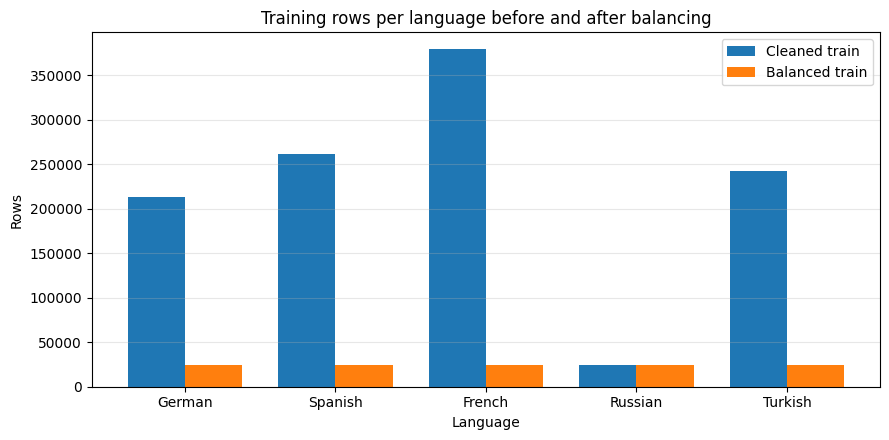

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(balancing_comparison_df))
width = 0.38

ax.bar(x - width / 2, balancing_comparison_df["cleaned_train_rows"], width=width, label="Cleaned train")
ax.bar(x + width / 2, balancing_comparison_df["balanced_train_rows"], width=width, label="Balanced train")
ax.set_xticks(x)
ax.set_xticklabels(balancing_comparison_df["language_name"])
ax.set_title("Training rows per language before and after balancing")
ax.set_xlabel("Language")
ax.set_ylabel("Rows")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 6. Prepare the Data for the Model

After cleaning and balancing, the datasets are converted into the final text-to-text format for mT5.


In [17]:
MODEL_INPUT_COLUMN = "model_input_text"
MODEL_TARGET_COLUMN = "model_target_text"

MODEL_COLUMNS_TO_KEEP = [
    LANGUAGE_COLUMN,
    TEXT_COLUMN,
    SUMMARY_COLUMN,
    ARTICLE_WORD_COUNT_COLUMN,
    SUMMARY_WORD_COUNT_COLUMN,
    MODEL_INPUT_COLUMN,
    MODEL_TARGET_COLUMN,
]


def build_model_input_text(article_text: str, language_code: str) -> str:
    language_name = LANGUAGE_NAMES[language_code]
    return f"summarize in {language_name}: {str(article_text).strip()}"


def add_model_text_columns(batch):
    return {
        MODEL_INPUT_COLUMN: [
            build_model_input_text(article_text, language_code)
            for article_text, language_code in zip(batch[TEXT_COLUMN], batch[LANGUAGE_COLUMN])
        ],
        MODEL_TARGET_COLUMN: [str(summary).strip() for summary in batch[SUMMARY_COLUMN]],
    }


prepared_datasets_by_language = {}

for language_code in LANGUAGE_CODES:
    print(f"Preparing model text for {language_code}...")
    prepared_datasets_by_language[language_code] = DatasetDict(
        {
            split_name: split_dataset.map(
                add_model_text_columns,
                batched=True,
                desc=f"Preparing {language_code}-{split_name}",
            )
            for split_name, split_dataset in balanced_datasets_by_language[language_code].items()
        }
    )

    for split_name in prepared_datasets_by_language[language_code].keys():
        current_columns = prepared_datasets_by_language[language_code][split_name].column_names
        columns_to_remove = [column for column in current_columns if column not in MODEL_COLUMNS_TO_KEEP]
        prepared_datasets_by_language[language_code][split_name] = prepared_datasets_by_language[language_code][split_name].remove_columns(columns_to_remove)

print("Model text columns are ready.")

Preparing model text for de...


Preparing de-train:   0%|          | 0/24849 [00:00<?, ? examples/s]

Preparing de-validation:   0%|          | 0/11037 [00:00<?, ? examples/s]

Preparing de-test:   0%|          | 0/10415 [00:00<?, ? examples/s]

Preparing model text for es...


...

Preparing model text for tr...


Preparing tr-train:   0%|          | 0/24849 [00:00<?, ? examples/s]

Preparing tr-validation:   0%|          | 0/10773 [00:00<?, ? examples/s]

Preparing tr-test:   0%|          | 0/11895 [00:00<?, ? examples/s]

Model text columns are ready.


In [18]:
final_dataset_dict = DatasetDict(
    {
        "train": concatenate_datasets(
            [prepared_datasets_by_language[language_code]["train"] for language_code in LANGUAGE_CODES]
        ).shuffle(seed=SEED),
        "validation": concatenate_datasets(
            [prepared_datasets_by_language[language_code]["validation"] for language_code in LANGUAGE_CODES]
        ).shuffle(seed=SEED),
        "test": concatenate_datasets(
            [prepared_datasets_by_language[language_code]["test"] for language_code in LANGUAGE_CODES]
        ).shuffle(seed=SEED),
    }
)

final_split_summary_df = pd.DataFrame(
    [
        {"split": split_name, "rows": len(split_dataset)}
        for split_name, split_dataset in final_dataset_dict.items()
    ]
)

final_train_distribution_df = pd.DataFrame(
    [
        {
            "language_code": language_code,
            "language_name": LANGUAGE_NAMES[language_code],
            "rows": len(prepared_datasets_by_language[language_code]["train"]),
        }
        for language_code in LANGUAGE_CODES
    ]
)

final_split_summary_df

,split,rows
0,train,124245
1,validation,48126
2,test,51933


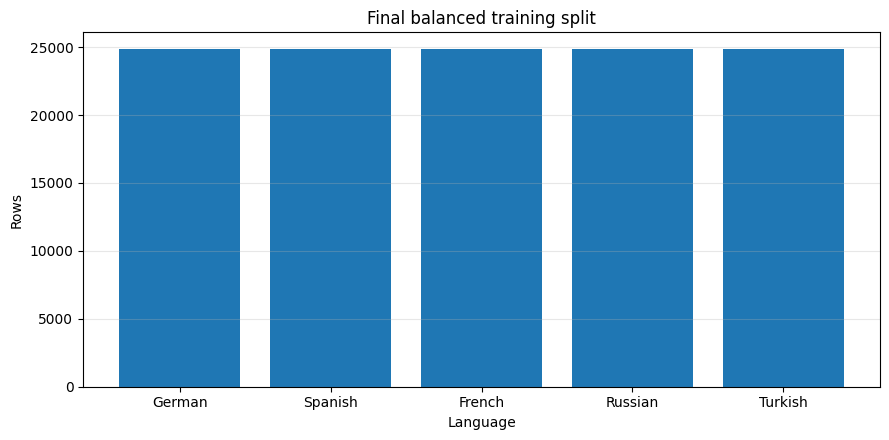

,language_code,language_name,rows
0,de,German,24849
1,es,Spanish,24849
2,fr,French,24849
3,ru,Russian,24849
4,tr,Turkish,24849


In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(final_train_distribution_df["language_name"], final_train_distribution_df["rows"])
ax.set_title("Final balanced training split")
ax.set_xlabel("Language")
ax.set_ylabel("Rows")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

final_train_distribution_df

# 7. Train the Model


In [20]:
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

In [21]:
TRAINING_OUTPUT_DIR = MODEL_DIR / "mt5_small_mlsum_multilingual"

NOTEBOOK_TRAIN_SUBSET_SIZE = 1000
NOTEBOOK_EVAL_SUBSET_SIZE = 100
NOTEBOOK_MAX_STEPS = 10

TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 0

LOGGING_STEPS = 5
EVAL_STEPS = 5
SAVE_STEPS = 5
EARLY_STOPPING_PATIENCE = 1

TOKENIZER_MAX_INPUT_LENGTH = 256
TOKENIZER_MAX_TARGET_LENGTH = 64

print("Training output directory:", TRAINING_OUTPUT_DIR)
print("Train subset size:", NOTEBOOK_TRAIN_SUBSET_SIZE)
print("Validation subset size:", NOTEBOOK_EVAL_SUBSET_SIZE)
print("Max training steps:", NOTEBOOK_MAX_STEPS)

Training output directory: /content/outputs/models/mt5_small_mlsum_multilingual
Train subset size: 1000
Validation subset size: 100
Max training steps: 10


In [22]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

if hasattr(model.config, "use_cache"):
    model.config.use_cache = False

print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model loaded:", model.__class__.__name__)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Tokenizer loaded: T5Tokenizer
Model loaded: MT5ForConditionalGeneration


In [23]:
def tokenize_seq2seq_batch(batch):
    model_inputs = tokenizer(
        batch[MODEL_INPUT_COLUMN],
        max_length=TOKENIZER_MAX_INPUT_LENGTH,
        truncation=True,
    )

    labels = tokenizer(
        text_target=batch[MODEL_TARGET_COLUMN],
        max_length=TOKENIZER_MAX_TARGET_LENGTH,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tokenized_dataset_dict = DatasetDict(
    {
        split_name: split_dataset.map(
            tokenize_seq2seq_batch,
            batched=True,
            remove_columns=split_dataset.column_names,
            desc=f"Tokenizing {split_name} split",
        )
        for split_name, split_dataset in final_dataset_dict.items()
    }
)

tokenized_dataset_dict

Tokenizing train split:   0%|          | 0/124245 [00:00<?, ? examples/s]

Tokenizing validation split:   0%|          | 0/48126 [00:00<?, ? examples/s]

Tokenizing test split:   0%|          | 0/51933 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 124245
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 48126
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 51933
    })
})

In [24]:
training_train_size = min(NOTEBOOK_TRAIN_SUBSET_SIZE, len(tokenized_dataset_dict["train"]))
training_eval_size = min(NOTEBOOK_EVAL_SUBSET_SIZE, len(tokenized_dataset_dict["validation"]))

training_dataset_dict = DatasetDict(
    {
        "train": tokenized_dataset_dict["train"].select(range(training_train_size)),
        "validation": tokenized_dataset_dict["validation"].select(range(training_eval_size)),
        "test": tokenized_dataset_dict["test"],
    }
)

pd.DataFrame(
    [
        {"split": split_name, "rows": len(split_dataset)}
        for split_name, split_dataset in training_dataset_dict.items()
    ]
)

,split,rows
0,train,1000
1,validation,100
2,test,51933


In [25]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [26]:
import inspect
import shutil

use_fp16 = torch.cuda.is_available()
use_bf16 = False

training_args_signature = inspect.signature(Seq2SeqTrainingArguments.__init__)
supported_training_args = set(training_args_signature.parameters.keys())

base_training_args = {
    "output_dir": str(TRAINING_OUTPUT_DIR),
    "do_train": True,
    "do_eval": True,
    "save_strategy": "steps",
    "logging_strategy": "steps",
    "eval_steps": EVAL_STEPS,
    "save_steps": SAVE_STEPS,
    "logging_steps": LOGGING_STEPS,
    "max_steps": NOTEBOOK_MAX_STEPS,
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_steps": WARMUP_STEPS,
    "predict_with_generate": False,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "save_total_limit": 2,
    "fp16": use_fp16,
    "bf16": use_bf16,
    "report_to": "none",
    "seed": SEED,
    "data_seed": SEED,
}

if "evaluation_strategy" in supported_training_args:
    base_training_args["evaluation_strategy"] = "steps"
elif "eval_strategy" in supported_training_args:
    base_training_args["eval_strategy"] = "steps"
else:
    raise ValueError("No compatible evaluation strategy argument found.")

if "overwrite_output_dir" in supported_training_args:
    base_training_args["overwrite_output_dir"] = True
elif TRAINING_OUTPUT_DIR.exists():
    shutil.rmtree(TRAINING_OUTPUT_DIR)

compatible_training_args = {
    key: value
    for key, value in base_training_args.items()
    if key in supported_training_args
}

training_args = Seq2SeqTrainingArguments(**compatible_training_args)
training_args

Seq2SeqTrainingArguments(output_dir='/content/outputs/models/mt5_small_mlsum_multilingual', do_train=True, do_eval=True, do_predict=False, eval_strategy=<IntervalStrategy.STEPS: 'steps'>, prediction_loss_only=False, per_device_train_batch_size=1, per_device_eval_batch_size=1, gradient_accumulation_steps=1, eval_accumulation_steps=None, eval_delay=0, torch_empty_cache_steps=None, learning_rate=0.0003, weight_decay=0.01, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=3.0, max_steps=10, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs=None, warmup_ratio=None, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir=None, logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=5, logging_nan_inf_filter=True, save_strategy=<SaveStrategy.STEPS: 'steps'>, save_steps=5, save_total_limit=2, enable_jit_checkpoint=False, save_on_each_node=False, save_on

In [27]:
trainer_signature = inspect.signature(Seq2SeqTrainer.__init__)
supported_trainer_args = set(trainer_signature.parameters.keys())

base_trainer_args = {
    "model": model,
    "args": training_args,
    "train_dataset": training_dataset_dict["train"],
    "eval_dataset": training_dataset_dict["validation"],
    "data_collator": data_collator,
    "callbacks": [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
}

if "processing_class" in supported_trainer_args:
    base_trainer_args["processing_class"] = tokenizer
elif "tokenizer" in supported_trainer_args:
    base_trainer_args["tokenizer"] = tokenizer

compatible_trainer_args = {
    key: value
    for key, value in base_trainer_args.items()
    if key in supported_trainer_args
}

trainer = Seq2SeqTrainer(**compatible_trainer_args)
trainer

In [28]:
train_result = trainer.train()
train_metrics = train_result.metrics
train_metrics

Step,Training Loss,Validation Loss
5,11.602380,18.131342
10,26.206293,19.284916


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


{'train_runtime': 776.7048,
 'train_samples_per_second': 0.013,
 'train_steps_per_second': 0.013,
 'total_flos': 2643748454400.0,
 'train_loss': 18.904336166381835,
 'epoch': 0.01}

In [29]:
trainer.save_model(str(TRAINING_OUTPUT_DIR))
tokenizer.save_pretrained(str(TRAINING_OUTPUT_DIR))
print("Saved model to:", TRAINING_OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /content/outputs/models/mt5_small_mlsum_multilingual


In [30]:
pd.DataFrame(
    [{"metric": key, "value": value} for key, value in train_metrics.items()]
).sort_values("metric").reset_index(drop=True)

,metric,value
0,epoch,1.000000e-02
1,total_flos,2.643748e+12
2,train_loss,1.890434e+01
3,train_runtime,7.767048e+02
4,train_samples_per_second,1.300000e-02
5,train_steps_per_second,1.300000e-02


# 8. Brief Model Check

A short ROUGE check is enough here because this is a summarization task.


In [31]:
from rouge_score import rouge_scorer

EVAL_VALIDATION_SAMPLE_SIZE = 100
GENERATION_MAX_NEW_TOKENS = 64
GENERATION_NUM_BEAMS = 2
EVAL_BATCH_SIZE_GENERATION = 4

brief_eval_dataset = final_dataset_dict["validation"].select(
    range(min(EVAL_VALIDATION_SAMPLE_SIZE, len(final_dataset_dict["validation"])))
)

print(f"Validation examples used for the brief check: {len(brief_eval_dataset):,}")

Validation examples used for the brief check: 100


In [32]:
def generate_summaries_for_dataset(
    dataset,
    batch_size: int = 4,
    max_input_length: int = 256,
    max_new_tokens: int = 64,
    num_beams: int = 2,
):
    all_predictions = []
    all_references = []
    all_languages = []

    model.eval()
    model.to(DEVICE)

    for start_idx in range(0, len(dataset), batch_size):
        end_idx = min(start_idx + batch_size, len(dataset))
        batch = dataset.select(range(start_idx, end_idx))

        tokenized_inputs = tokenizer(
            batch[MODEL_INPUT_COLUMN],
            padding=True,
            truncation=True,
            max_length=max_input_length,
            return_tensors="pt",
        )

        tokenized_inputs = {key: value.to(model.device) for key, value in tokenized_inputs.items()}

        with torch.no_grad():
            generated_tokens = model.generate(
                **tokenized_inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
            )

        batch_predictions = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        all_predictions.extend([prediction.strip() for prediction in batch_predictions])
        all_references.extend([reference.strip() for reference in batch[MODEL_TARGET_COLUMN]])
        all_languages.extend(batch[LANGUAGE_COLUMN])

    return pd.DataFrame(
        {
            "language_code": all_languages,
            "reference_summary": all_references,
            "predicted_summary": all_predictions,
        }
    )


brief_eval_predictions_df = generate_summaries_for_dataset(
    brief_eval_dataset,
    batch_size=EVAL_BATCH_SIZE_GENERATION,
    max_input_length=TOKENIZER_MAX_INPUT_LENGTH,
    max_new_tokens=GENERATION_MAX_NEW_TOKENS,
    num_beams=GENERATION_NUM_BEAMS,
)

brief_eval_predictions_df.head()

,language_code,reference_summary,predicted_summary
0,es,"La festividad de Año Nuevo y el auge de la clase media impulsan la venta de esta fruta, símbolo de prosperidad y bue...",<extra_id_0>.
1,es,El tribunal mantuvo la prisión al expresidente de la alianza Nissan-Renault para evitar el riesgo de fuga y la ocult...,<extra_id_0>.
2,es,"El garbanzo, fundamental en esta comida, se importa más que se siembra",<extra_id_0>.
3,fr,"Pour construire un monde nouveau en Algérie, il faut « commencer par le début » : abroger un code de la famille arch...",<extra_id_0>.
4,tr,"Çocuk Sağlığı ve Hastalıkları Uzmanı Dr. Gülfer Akça, mevsim itibariyle yoğun influenza salgınının yaşandığı bu döne...",<extra_id_0> edilir.


In [33]:
def compute_mean_rouge_scores(predictions_df: pd.DataFrame) -> pd.DataFrame:
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)

    aggregate_scores = {"rouge1": [], "rouge2": [], "rougeL": []}

    for reference, prediction in zip(
        predictions_df["reference_summary"],
        predictions_df["predicted_summary"],
    ):
        score = scorer.score(reference, prediction)
        aggregate_scores["rouge1"].append(score["rouge1"].fmeasure)
        aggregate_scores["rouge2"].append(score["rouge2"].fmeasure)
        aggregate_scores["rougeL"].append(score["rougeL"].fmeasure)

    return pd.DataFrame(
        [
            {"metric": metric_name, "value": round(float(np.mean(values)), 4)}
            for metric_name, values in aggregate_scores.items()
        ]
    ).sort_values("metric").reset_index(drop=True)


brief_eval_rouge_df = compute_mean_rouge_scores(brief_eval_predictions_df)
print("Brief validation quality check")
print("-" * 40)
brief_eval_rouge_df

Brief validation quality check
----------------------------------------


,metric,value
0,rouge1,0.0078
1,rouge2,0.0031
2,rougeL,0.0078
